<a href="https://colab.research.google.com/github/Stefanpu13/AIClub/blob/master/Copy_of_neural_networks_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

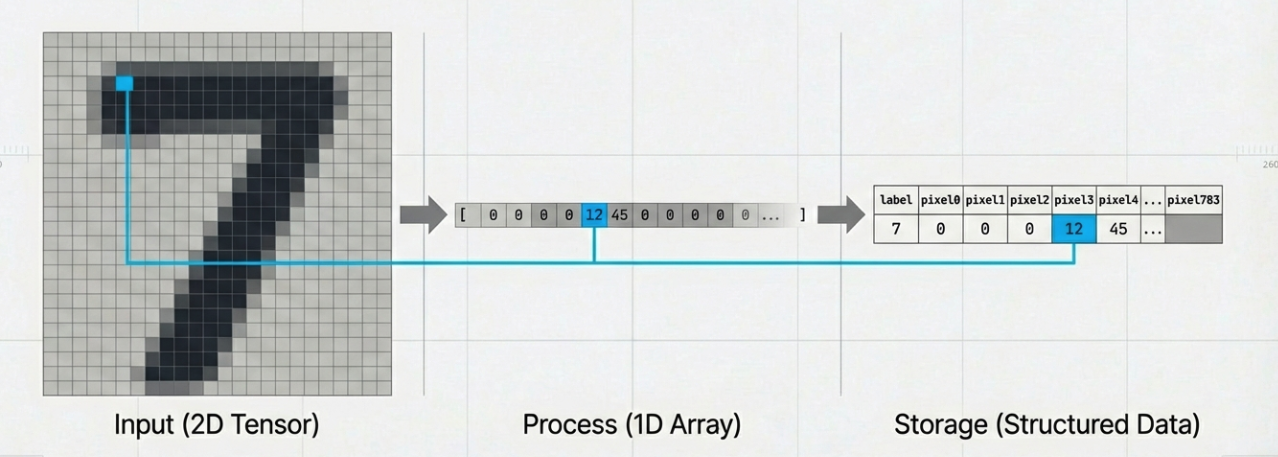

In [ ]:
# =============================
# 1) Download and load dataset
# =============================
import pandas as pd
import numpy as np
import gdown
import matplotlib.pyplot as plt
import os
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import LabelEncoder

FILE_ID = "1UaJlVU9wIjjV7ilrlgoHmEgMzf0SEiPi"
OUT_PATH = "dataset.csv"

gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", OUT_PATH, quiet=False)

mnist_file = pd.read_csv(OUT_PATH)

print("Dataset shape:", mnist_file.shape)
print("\nFirst 5 rows:")
print(mnist_file.head())
label_counts = mnist_file["label"].value_counts()
label_perc = mnist_file["label"].value_counts(normalize=True) * 100
display(pd.DataFrame({"count": label_counts, "percent": label_perc.round(2)}))

In [ ]:
# Pick a line in the csv file
line_number = 1

# Print the digit in this line
print('True value is : ', mnist_file.iloc[line_number,0])

# Visualize the input to the AI
image_sample = np.array(mnist_file.iloc[line_number,1:]).reshape(28,28)


imgplot = plt.imshow(image_sample, cmap='gray')
plt.show()

In [ ]:
# ------------------------------------------------------------
# 0) Work on a copy of the file
# ------------------------------------------------------------
df = mnist_file.copy()

# ------------------------------------------------------------
# 1) Build X (feature), y (label)
# ------------------------------------------------------------
y = df["label"].values.astype(np.int64)
X = df.drop(columns=["label"]).values.astype(np.float32) / 255.0  # normalize to 0..1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

In [ ]:
# ------------------------------------------------------------
# 2) Build a tiny neural net: 784 -> 32 -> 10
# ------------------------------------------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(32, activation="relu", name="fc1"),
    tf.keras.layers.Dense(10, activation=None, name="fc2")  # logits
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

def draw_dense_network(layer_sizes, max_nodes_per_layer=10, title="Dense Neural Network"):
    import numpy as np
    import matplotlib.pyplot as plt

    # If a layer is bigger than this, we show top+bottom neurons with a "⋮" gap
    show_gap = True
    top_k = max_nodes_per_layer // 2
    bottom_k = max_nodes_per_layer - top_k

    xs = np.linspace(0.1, 0.9, len(layer_sizes))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis("off")

    # Give room for the title so it doesn't overlap
    fig.subplots_adjust(top=0.80)
    fig.suptitle(title, y=0.98)

    layer_points = []  # list of lists of node (x,y) positions actually drawn

    for li, (x, true_n) in enumerate(zip(xs, layer_sizes)):
        # vertical range for nodes
        y_top, y_bot = 0.80, 0.15

        pts = []

        if true_n <= max_nodes_per_layer:
            # draw all nodes
            ys = np.linspace(y_bot, y_top, true_n)
            pts = [(x, y) for y in ys]

        else:
            # draw top_k + bottom_k, with a gap in between
            ys_top = np.linspace(y_top, 0.60, top_k)      # top group
            ys_bot = np.linspace(0.35, y_bot, bottom_k)   # bottom group
            pts = [(x, y) for y in ys_top] + [(x, y) for y in ys_bot]

            # draw the vertical ellipsis in the gap
            ax.text(x, 0.48, "⋮", ha="center", va="center", fontsize=18)

        layer_points.append(pts)

        # draw nodes
        for (px, py) in pts:
            ax.add_patch(plt.Circle((px, py), 0.015, fill=True))

        # layer label
        ax.text(x, 0.88, f"Layer {li} ({true_n})", ha="center", va="top", fontsize=10)

    # draw connections (only between displayed nodes to keep it readable)
    for li in range(len(layer_sizes) - 1):
        for (x1, y1) in layer_points[li]:
            for (x2, y2) in layer_points[li + 1]:
                ax.plot([x1, x2], [y1, y2], linewidth=0.5, alpha=0.25)

    plt.show()


# Example
draw_dense_network([784, 32, 10], max_nodes_per_layer=10,
                   title="Dense NN: 784 → 32 → 10 (showing subset; ⋮ means more neurons)")

In [ ]:
# ------------------------------------------------------------
# 4) Heatmap helpers
# ------------------------------------------------------------
def show_weight_heatmap(W, title, figsize=(10, 4)):
    plt.figure(figsize=figsize)
    plt.imshow(W, aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Input dimension")
    plt.ylabel("Output neuron")
    plt.show()

def show_hidden_neuron_as_image(W_fc1, neuron_idx=0, title=""):
    # Keras Dense weights are (in_features, out_features)
    # For neuron k, we take column k, shape (784,)
    w = W_fc1[:, neuron_idx].reshape(28, 28)
    plt.figure(figsize=(3, 3))
    plt.imshow(w, cmap="gray")
    plt.colorbar()
    plt.title(title if title else f"Hidden neuron {neuron_idx} weights as 28×28")
    plt.axis("off")
    plt.show()

In [ ]:
# ------------------------------------------------------------
# 5) Get RANDOM init weights (force build by calling once)
# ------------------------------------------------------------
_ = model(X_train[:1])  # ensures weights exist

W1_before, b1_before = model.get_layer("fc1").get_weights()  # shapes: (784,32), (32,)
W2_before, b2_before = model.get_layer("fc2").get_weights()  # shapes: (32,10), (10,)

print("\nRandom initialization snapshot:")
print("fc1 weights shape:", W1_before.shape, "(784 x 32)")
print("fc2 weights shape:", W2_before.shape, "(32 x 10)")
print("fc1 first 10 weights into neuron0:", W1_before[:10, 0])
print("fc2 first 10 weights into class0:", W2_before[:10, 0])

# Heatmaps (transpose so it looks like: (neurons_out x inputs_in))
show_weight_heatmap(W1_before.T, "fc1 weights BEFORE training (32×784)")
show_weight_heatmap(W2_before.T, "fc2 weights BEFORE training (10×32)")
show_hidden_neuron_as_image(W1_before, neuron_idx=0, title="Neuron 0 (fc1) BEFORE training")

In [ ]:
# ------------------------------------------------------------
# 6) Train (simple)
# ------------------------------------------------------------
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

# ------------------------------------------------------------
# 7) Performance + confusion matrix (test)
# ------------------------------------------------------------
logits = model.predict(X_test, verbose=0)
preds = np.argmax(logits, axis=1)

acc = accuracy_score(y_test, preds)
print("\nFinal test accuracy:", acc)

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=[str(i) for i in range(10)]).plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()


In [ ]:
# ------------------------------------------------------------
# 8) Weights AFTER training + heatmaps + DELTA
# ------------------------------------------------------------
W1_after, b1_after = model.get_layer("fc1").get_weights()
W2_after, b2_after = model.get_layer("fc2").get_weights()

show_weight_heatmap(W1_after.T, "fc1 weights AFTER training (32×784)")
show_weight_heatmap(W2_after.T, "fc2 weights AFTER training (10×32)")

show_weight_heatmap((W1_after - W1_before).T, "fc1 weight CHANGE (after − before) (32×784)")
show_weight_heatmap((W2_after - W2_before).T, "fc2 weight CHANGE (after − before) (10×32)")


print("\nWeight change summary:")
print("fc1 L2 change:", np.linalg.norm(W1_after - W1_before))
print("fc2 L2 change:", np.linalg.norm(W2_after - W2_before))
print("fc1 first 10 weights into neuron0 (before):", W1_before[:10, 0])
print("fc1 first 10 weights into neuron0 (after) :", W1_after[:10, 0])

In [ ]:
MODEL_PATH = "simple_mnist_tf_model.keras"

model.save(MODEL_PATH)

# Now measure size properly (it's a file)
import os

size_bytes = os.path.getsize(MODEL_PATH)

print("Saved model to:", MODEL_PATH)
print(f"Model size: {size_bytes} bytes "
      f"({size_bytes/1024:.2f} KB, {size_bytes/1024/1024:.4f} MB)")